In [1]:
# Add project root to Python path
# This is needed so the notebook can import from src/ folder
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')
print('Path configured successfully.')

Project root: /Users/macbookpro/Documents/SLITT/IT5022/rain_prediction
Path configured successfully.


In [2]:
from src.data_loader   import load_dataset
from src.preprocessing import run_preprocessing
from src.eda           import run_eda
from src.models        import train_decision_tree, train_random_forest
from src.evaluation    import (
    evaluate_model, plot_confusion_and_roc,
    plot_decision_tree_visual, plot_feature_importance,
    plot_comparison, run_cross_validation
)
from src.predictor     import predict_rain_for_date, plot_prediction_chart

import warnings
warnings.filterwarnings('ignore')

print('All modules imported successfully.')

All modules imported successfully.


In [3]:
# Load the dataset and display the first five rows
df_raw = load_dataset()
df_raw.head()

Loading dataset from: /Users/macbookpro/Documents/SLITT/IT5022/rain_prediction/data/SriLanka_Weather_Dataset_V1.csv

Dataset loaded successfully.
  Rows    : 147,480
  Columns : 24
  Columns : ['time', 'weathercode', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'sunrise', 'sunset', 'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max', 'winddirection_10m_dominant', 'et0_fao_evapotranspiration', 'latitude', 'longitude', 'elevation', 'country', 'city']

No missing values found.

Unique cities (30): ['Athurugiriya', 'Badulla', 'Bentota', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Hatton', 'Jaffna', 'Kalmunai', 'Kalutara', 'Kandy', 'Kesbewa', 'Kolonnawa', 'Kurunegala', 'Mabole', 'Maharagama', 'Mannar', 'Matale', 'Matara', 'Moratuwa', 'Mount Lavinia', 'Negombo', 'Oruwala', 'Pothuhera', 'Puttalam', 

,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,...,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,country,city
0,1/1/2010,2,30.0,22.7,26.1,34.4,25.2,29.2,6:22:00 AM,6:05:00 PM,...,0,11.7,27.4,20,4.58,7.0,79.899994,16,Sri Lanka,Colombo
1,1/2/2010,51,29.9,23.5,26.2,33.8,26.2,29.8,6:22:00 AM,6:06:00 PM,...,1,13.0,27.0,24,3.84,7.0,79.899994,16,Sri Lanka,Colombo
2,1/3/2010,51,29.5,23.2,26.0,34.3,26.3,29.9,6:23:00 AM,6:06:00 PM,...,3,12.3,27.4,16,3.65,7.0,79.899994,16,Sri Lanka,Colombo
3,1/4/2010,2,28.9,21.9,25.3,31.6,23.4,27.8,6:23:00 AM,6:07:00 PM,...,0,17.0,34.6,356,3.79,7.0,79.899994,16,Sri Lanka,Colombo
4,1/5/2010,1,28.1,21.3,24.5,30.1,23.1,26.1,6:23:00 AM,6:07:00 PM,...,0,18.7,37.1,355,4.97,7.0,79.899994,16,Sri Lanka,Colombo


EXPLORATORY DATA ANALYSIS

Data Types:
time                           object
weathercode                     int64
temperature_2m_max            float64
temperature_2m_min            float64
temperature_2m_mean           float64
apparent_temperature_max      float64
apparent_temperature_min      float64
apparent_temperature_mean     float64
sunrise                        object
sunset                         object
shortwave_radiation_sum       float64
precipitation_sum             float64
rain_sum                      float64
snowfall_sum                    int64
precipitation_hours             int64
windspeed_10m_max             float64
windgusts_10m_max             float64
winddirection_10m_dominant      int64
et0_fao_evapotranspiration    float64
latitude                      float64
longitude                     float64
elevation                       int64
country                        object
city                           object
dtype: object

Statistical Summary:
         weat

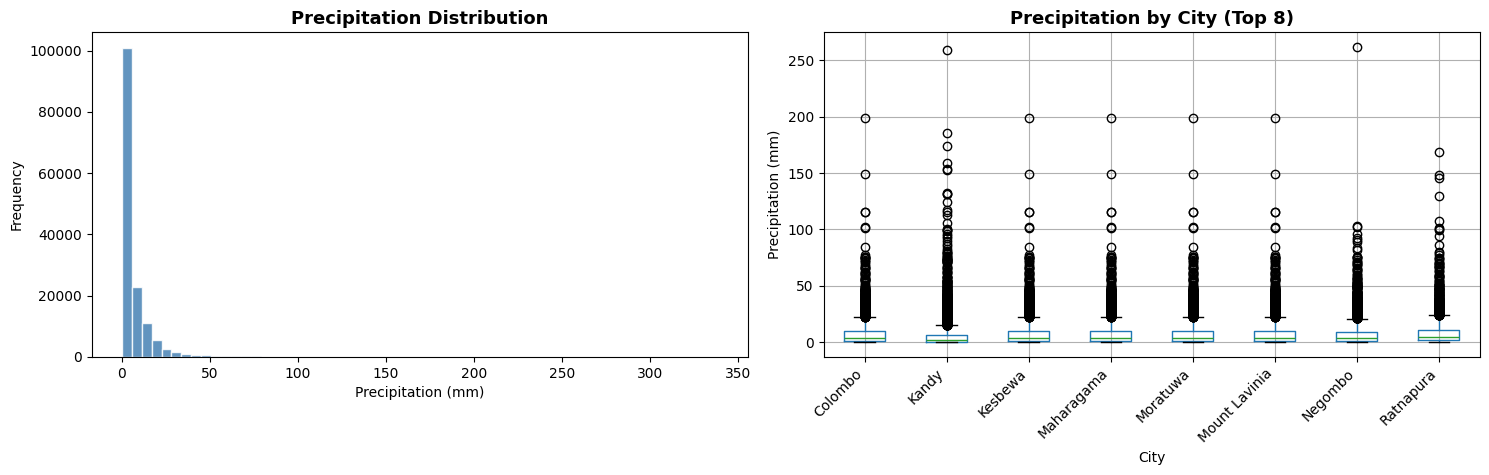

In [4]:
# Run EDA (before preprocessing)
# We run EDA on raw data to understand it before any transformation
#
run_eda(df_raw)

In [5]:
# Run preprocessing to identify available features, missing values and split data to train set and test set

df, X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_cols = \
    run_preprocessing(df_raw.copy())

PREPROCESSING PIPELINE
Date parsed and dataset sorted by city + date.

Target variable "RainTomorrow" created.
  Rain    (1) : 96,845  (65.7%)
  No Rain (0) : 50,635  (34.3%)

Features available : 14

Feature matrix X : (147480, 14)
Target vector  y : (147480,)
Missing values   : 0

Train/Test Split (stratified):
  Training set : 117,984 samples
  Test set     : 29,496 samples
  Train balance: {1: 77476, 0: 40508}
  Test  balance: {1: 19369, 0: 10127}

StandardScaler applied.
  Fit on training set only (prevents data leakage).

Preprocessing complete.


In [8]:
# Run preprocessing to identify available features, missing values and split data to train set and test set
(df, X_train_scaled, X_test_scaled, y_train, y_test,
 scaler, feature_cols) = run_preprocessing(df_raw.copy())

PREPROCESSING PIPELINE
Date parsed and dataset sorted by city + date.

Target variable "RainTomorrow" created.
  Rain    (1) : 96,845  (65.7%)
  No Rain (0) : 50,635  (34.3%)

Features available : 14

Feature matrix X : (147480, 14)
Target vector  y : (147480,)
Missing values   : 0

Train/Test Split (stratified):
  Training set : 117,984 samples
  Test set     : 29,496 samples
  Train balance: {1: 77476, 0: 40508}
  Test  balance: {1: 19369, 0: 10127}

StandardScaler applied.
  Fit on training set only (prevents data leakage).

Preprocessing complete.


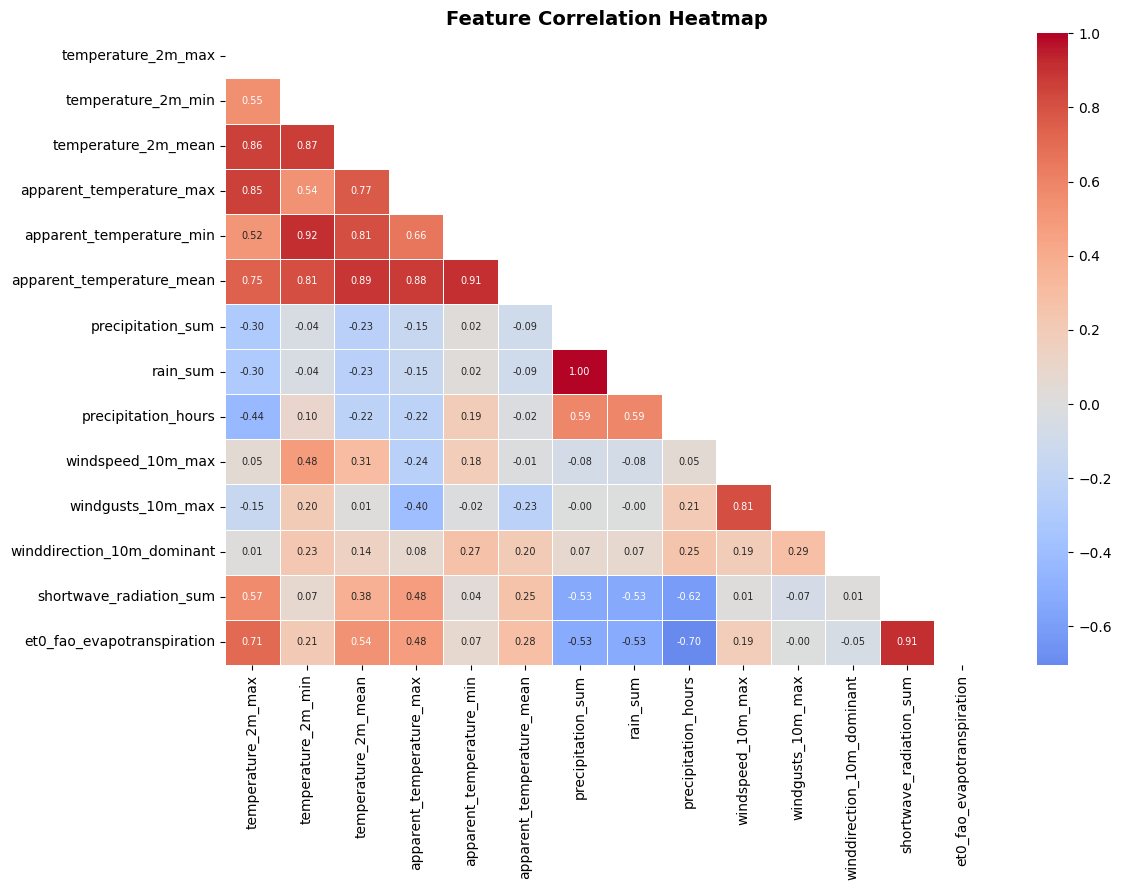

In [9]:
# EDA after preprocessing to display correlation heatmap with final features
import pandas as pd
X_full = df[feature_cols].fillna(df[feature_cols].median())
from src.eda import plot_correlation_heatmap
plot_correlation_heatmap(X_full)

In [ ]:
# Algorithm 1
# Train Decision Tree
dt_model = train_decision_tree(X_train_scaled, y_train)

In [ ]:
# Evaluate Decision Tree
# evaluate_model() will returns all metrics needed for comparison
dt_metrics = evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree')

In [ ]:
# visualize Confusion Matrix and ROC Curve
plot_confusion_and_roc(dt_metrics, cmap='Blues', y_test=y_test)

In [ ]:
# Visualize the tree (top 3 levels)
plot_decision_tree_visual(dt_model, feature_cols)

In [ ]:
# Algorithm 2
# Train Random Forest
rf_model = train_random_forest(X_train_scaled, y_train)

In [ ]:
# Evaluate Random Forest
rf_metrics = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest')

In [ ]:
# Confusion Matrix + ROC Curve
plot_confusion_and_roc(rf_metrics, cmap='Greens', y_test=y_test)

In [ ]:
# Feature Importances
plot_feature_importance(rf_model, feature_cols)

In [ ]:
##  Algorithm Comparison
# Compare both algorithms
plot_comparison(dt_metrics, rf_metrics)

In [ ]:
# 5-Fold Cross Validation
run_cross_validation(dt_model, rf_model, X_train_scaled, y_train)

In [ ]:
# PREDICT FOR ANY DATE AND CITY

QUERY_DATE = '2021-06-15'    # Format: YYYY-MM-DD
QUERY_CITY = 'Colombo'       # city name


predict_rain_for_date(
    input_date   = QUERY_DATE,
    input_city   = QUERY_CITY,
    df           = df,
    dt_model     = dt_model,
    rf_model     = rf_model,
    scaler       = scaler,
    feature_cols = feature_cols
)

In [ ]:
#  Visualise prediction as probability bar chart
plot_prediction_chart(
    input_date   = QUERY_DATE,
    input_city   = QUERY_CITY,
    df           = df,
    dt_model     = dt_model,
    rf_model     = rf_model,
    scaler       = scaler,
    feature_cols = feature_cols
)

In [ ]:
#  Predict for multiple dates and cities
test_cases = [
    ('2020-10-20', 'Colombo'),
    ('2018-12-01', 'Kandy'),
    ('2015-04-10', 'Galle'),
    ('2019-08-25', 'Jaffna'),
]

for date, city in test_cases:
    predict_rain_for_date(date, city, df, dt_model, rf_model, scaler, feature_cols)
    print()